In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import re
import pandas as pd
import seaborn as sns

In [2]:
data_dir = "../output/"
runs = os.listdir(data_dir)
print(len(runs))

690


In [3]:
METRIC_PATTERNS = {
    "total_cycle": re.compile(r"total cycle =\s*(\d+)"),
    "load_cycle": re.compile(r"load cycle =\s*(\d+)"),
    "multiply_cycle": re.compile(r"multiply cycle =\s*(\d+)"),
    "merge_writeback_cycle": re.compile(r"merge and writeback cycle =\s*(\d+)"),
    "total_sram_cycle": re.compile(r"total SRAM cycle =\s*(\d+)"),
    "total_dram_cycle": re.compile(r"total DRAM cycle =\s*(\d+)"),
    "total_pe_cycle": re.compile(r"total PE cycle =\s*(\d+)"),
    "total_dram_access_a": re.compile(r"total DRAM access A =\s*(\d+)"),
    "total_dram_access_b": re.compile(r"total DRAM access B =\s*(\d+)"),
    "total_dram_access_c": re.compile(r"total DRAM access C =\s*(\d+)"),
    "hitrate": re.compile(r"hitrate =\s*([0-9eE+\-.]+)"),
}

config_fields = re.compile(r'CGust(\w+)_(\d+\.\d+)MB_(\d+\.\d+)GBs_(\d+)PEs_(\d+)sbanks__([\w.-]+)_(\d)_data_(\d)_coord_(\d)\.txt')
def parse_config_from_filename(filename):
    match = config_fields.match(filename)
    if not match:
        print(filename)
    mode, sram_mb, dram_bandwidth_gbs, pes, sram_banks, matrix_name, transpose, data_bytes, coord_bytes = match.groups()
    return pd.Series({
            'mode'               : mode
           ,'sram_mb'            : sram_mb
           ,'dram_bandwidth_gbs' : dram_bandwidth_gbs
           ,'pes'                : pes
           ,'sram_banks'         : sram_banks
           ,'transpose'          : True if transpose == '1' else False
           ,'data_bytes'         : data_bytes
           ,'coord_bytes'        : coord_bytes
           ,'matrix type'        : 'dense' if 'dense' in filename else 'sparse'
           ,'matrix'             : matrix_name[:len(matrix_name)//2 - 2]
           })

def parse_runs(filenames):
    rows = []
    bad_data = []
    for file in filenames:
        with open(data_dir + file, 'r') as f:
            text = f.read()
            columns = {key:METRIC_PATTERNS[key].findall(text) for key in METRIC_PATTERNS}

        
        min_len = min([len(columns[key]) for key in columns])
        if min_len == 0:
            bad_data.append(file)
            continue
        
        columns['file'] = [file] * min_len
        columns['testcase'] = ['CurrentCache', 'SeaCache', 'InnerSP', 'Sparch', 'X-cache', 'Scratchpad']

        
        data = pd.DataFrame.from_dict({key:columns[key][:min_len] for key in columns})
        rows.append(data)
    return pd.concat(rows), bad_data

In [4]:
df, bad_runs = parse_runs(runs)
print(len(bad_runs))
df.info()

90
<class 'pandas.DataFrame'>
Index: 3600 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_cycle            3600 non-null   str  
 1   load_cycle             3600 non-null   str  
 2   multiply_cycle         3600 non-null   str  
 3   merge_writeback_cycle  3600 non-null   str  
 4   total_sram_cycle       3600 non-null   str  
 5   total_dram_cycle       3600 non-null   str  
 6   total_pe_cycle         3600 non-null   str  
 7   total_dram_access_a    3600 non-null   str  
 8   total_dram_access_b    3600 non-null   str  
 9   total_dram_access_c    3600 non-null   str  
 10  hitrate                3600 non-null   str  
 11  file                   3600 non-null   str  
 12  testcase               3600 non-null   str  
dtypes: str(13)
memory usage: 393.8 KB


In [5]:
configs = df.file.apply(parse_config_from_filename)
data = pd.concat([df, configs], axis=1).reset_index(drop=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_cycle            3600 non-null   str  
 1   load_cycle             3600 non-null   str  
 2   multiply_cycle         3600 non-null   str  
 3   merge_writeback_cycle  3600 non-null   str  
 4   total_sram_cycle       3600 non-null   str  
 5   total_dram_cycle       3600 non-null   str  
 6   total_pe_cycle         3600 non-null   str  
 7   total_dram_access_a    3600 non-null   str  
 8   total_dram_access_b    3600 non-null   str  
 9   total_dram_access_c    3600 non-null   str  
 10  hitrate                3600 non-null   str  
 11  file                   3600 non-null   str  
 12  testcase               3600 non-null   str  
 13  mode                   3600 non-null   str  
 14  sram_mb                3600 non-null   str  
 15  dram_bandwidth_gbs     3600 non-null   str  
 16 

In [6]:
numeric_cols = [col for col in data.columns if 'file' not in col and 'testcase' not in col and 'mode' not in col and 'matrix' not in col]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_cycle            3600 non-null   int64  
 1   load_cycle             3600 non-null   int64  
 2   multiply_cycle         3600 non-null   int64  
 3   merge_writeback_cycle  3600 non-null   int64  
 4   total_sram_cycle       3600 non-null   int64  
 5   total_dram_cycle       3600 non-null   int64  
 6   total_pe_cycle         3600 non-null   int64  
 7   total_dram_access_a    3600 non-null   int64  
 8   total_dram_access_b    3600 non-null   int64  
 9   total_dram_access_c    3600 non-null   int64  
 10  hitrate                3000 non-null   float64
 11  file                   3600 non-null   str    
 12  testcase               3600 non-null   str    
 13  mode                   3600 non-null   str    
 14  sram_mb                3600 non-null   float64
 15  dram_bandwidth_

In [7]:
data.to_csv('../output/parsed_data.csv')

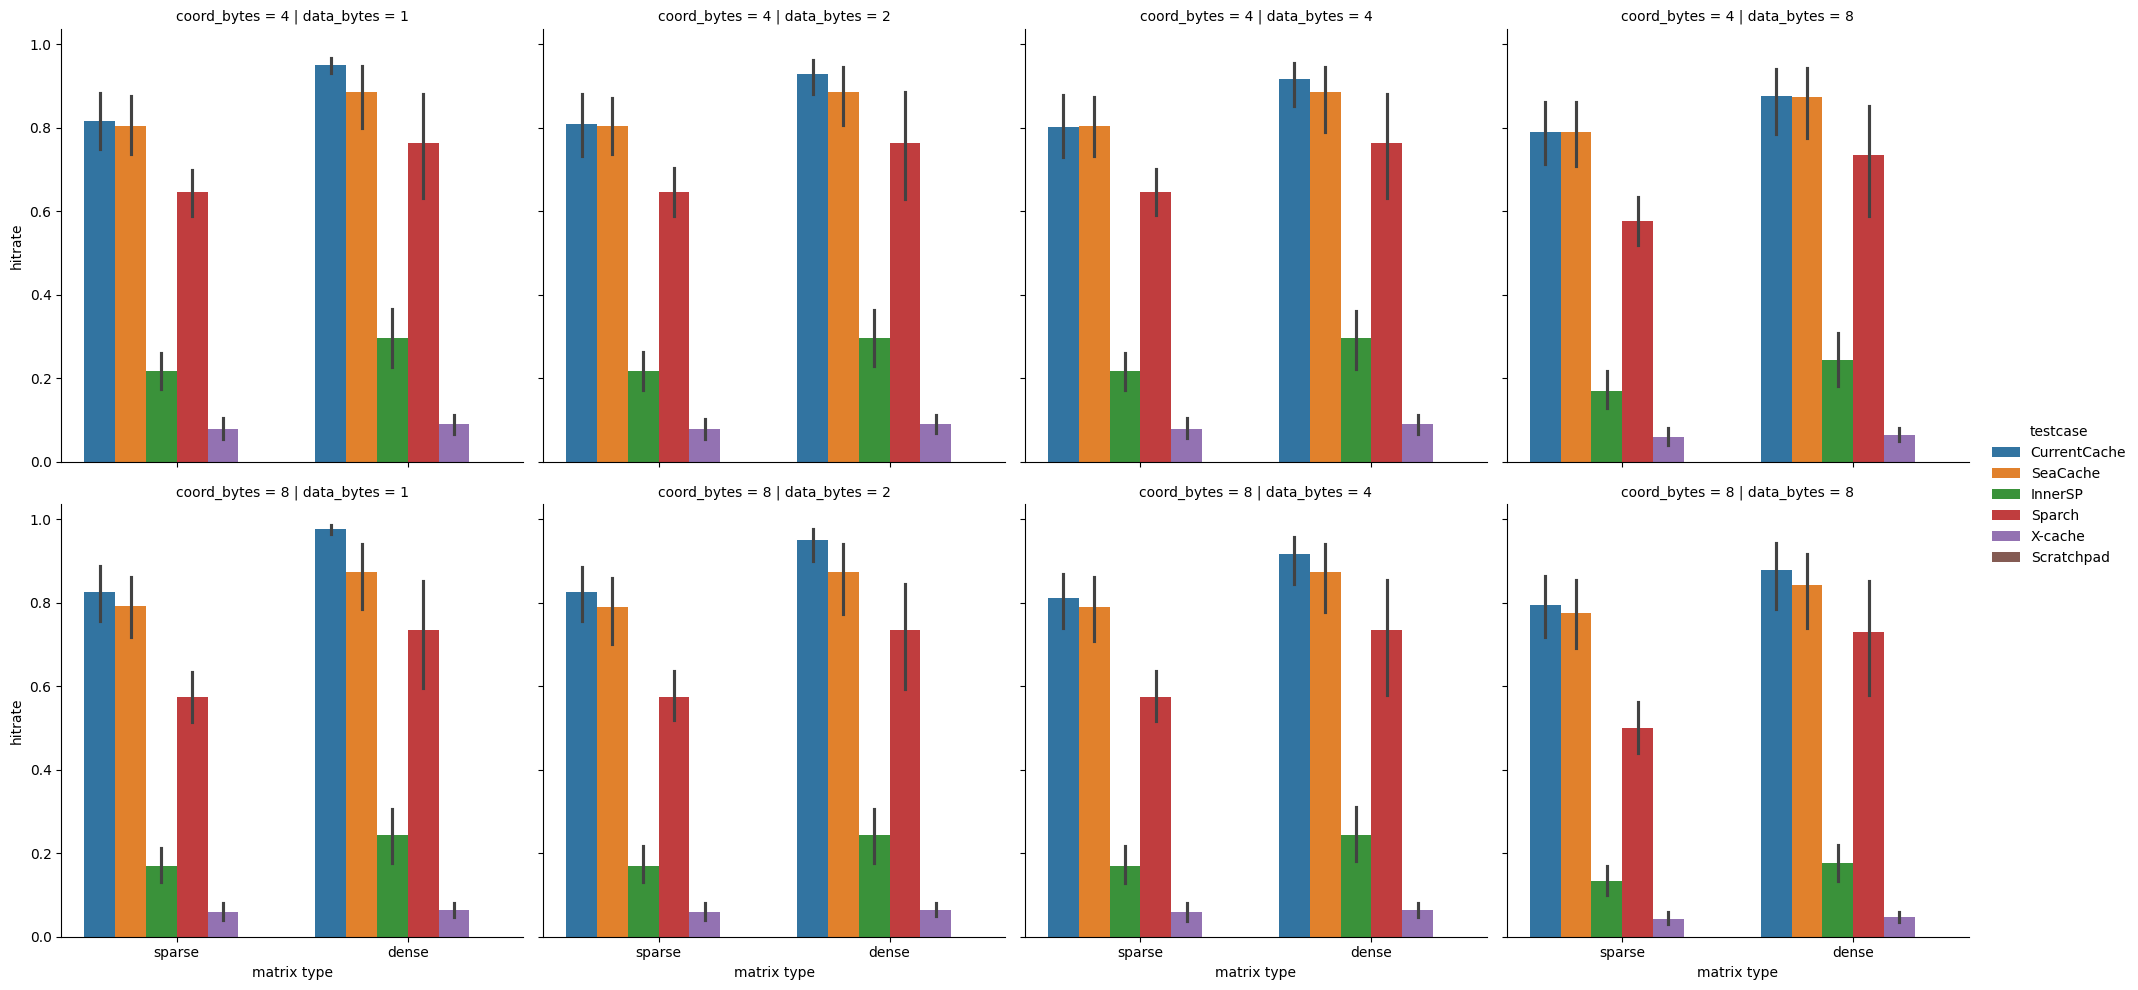

In [8]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='hitrate', hue='testcase', kind='bar', x='matrix type')
plt.savefig('../renderings/hitrate.png')

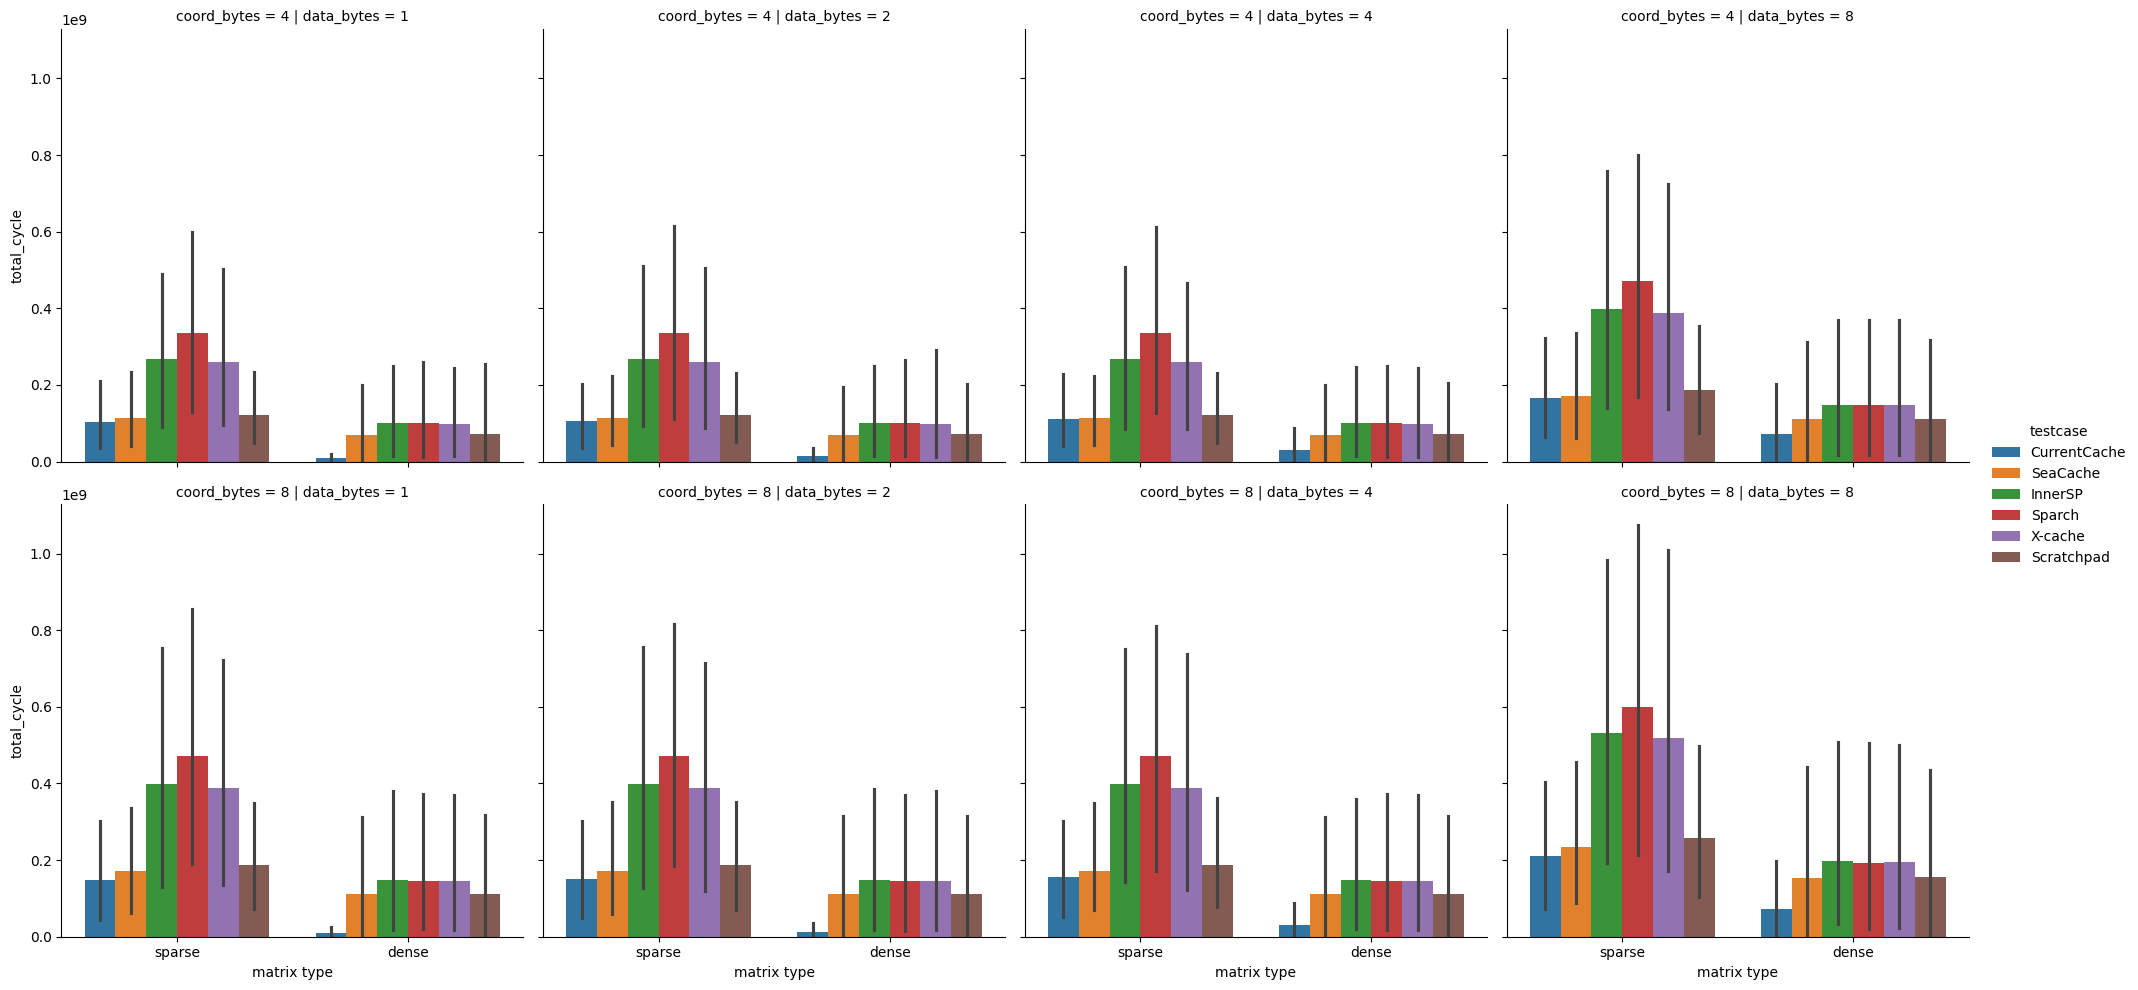

In [9]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='total_cycle', hue='testcase', kind='bar', x='matrix type')

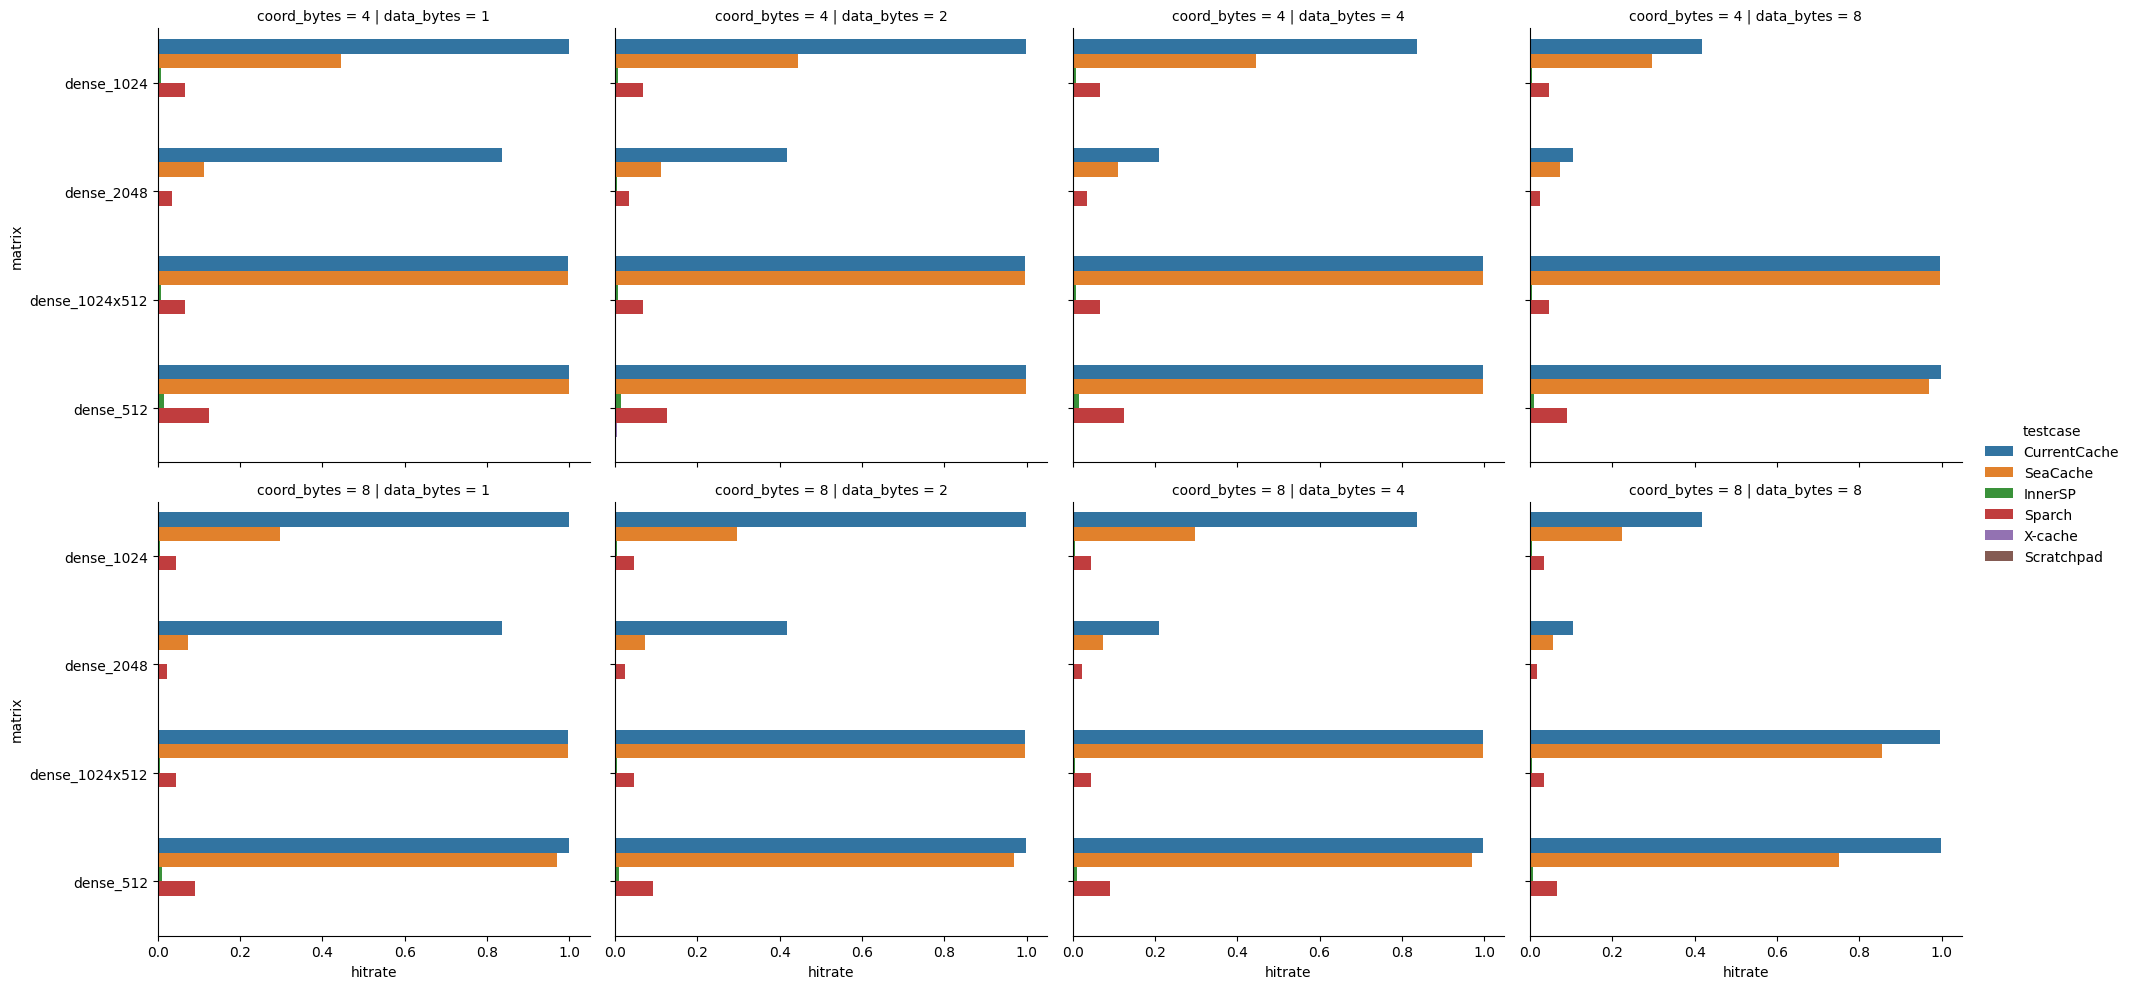

In [10]:
mask = data['matrix'].str.contains('dense_1024') | data['matrix'].str.contains('dense_512') | data['matrix'].str.contains('dense_2048')
sns.catplot(data=data.loc[mask], x='hitrate', y='matrix', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/dense_sweep.png')

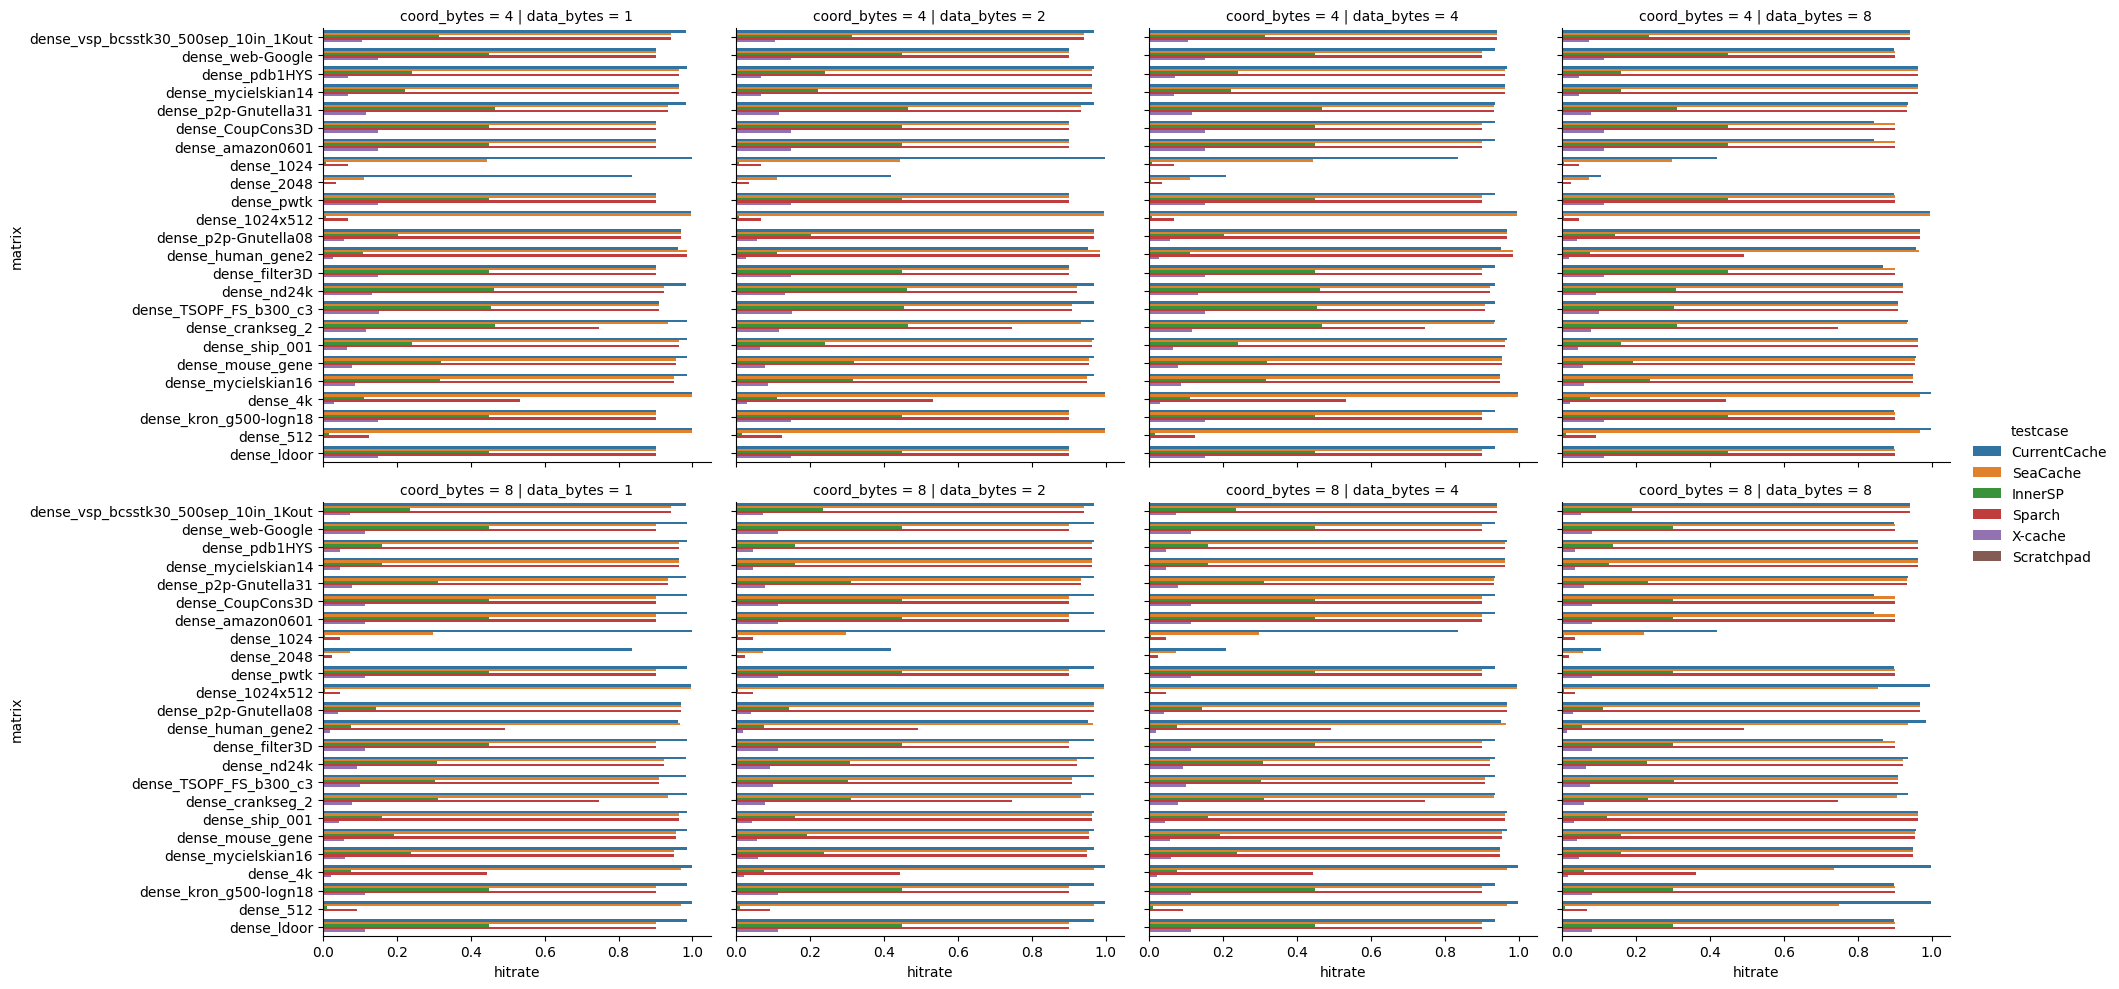

In [11]:
mask = data['matrix'].str.contains('dense')
sns.catplot(data=data.loc[mask], x='hitrate', y='matrix', hue='testcase', orient='h', aspect=1, height=5, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/full_dense_sweep.png')

In [12]:
data['normalized_cyc'] = 0.
mask = data.testcase == 'SeaCache'
compare_point = data.loc[mask].set_index('matrix').total_cycle
for testcase in data['testcase'].unique():
    mask = data.testcase == testcase
    tmp = compare_point / data.loc[mask].set_index('matrix').total_cycle
    data.loc[mask, 'normalized_cyc'] = tmp.values


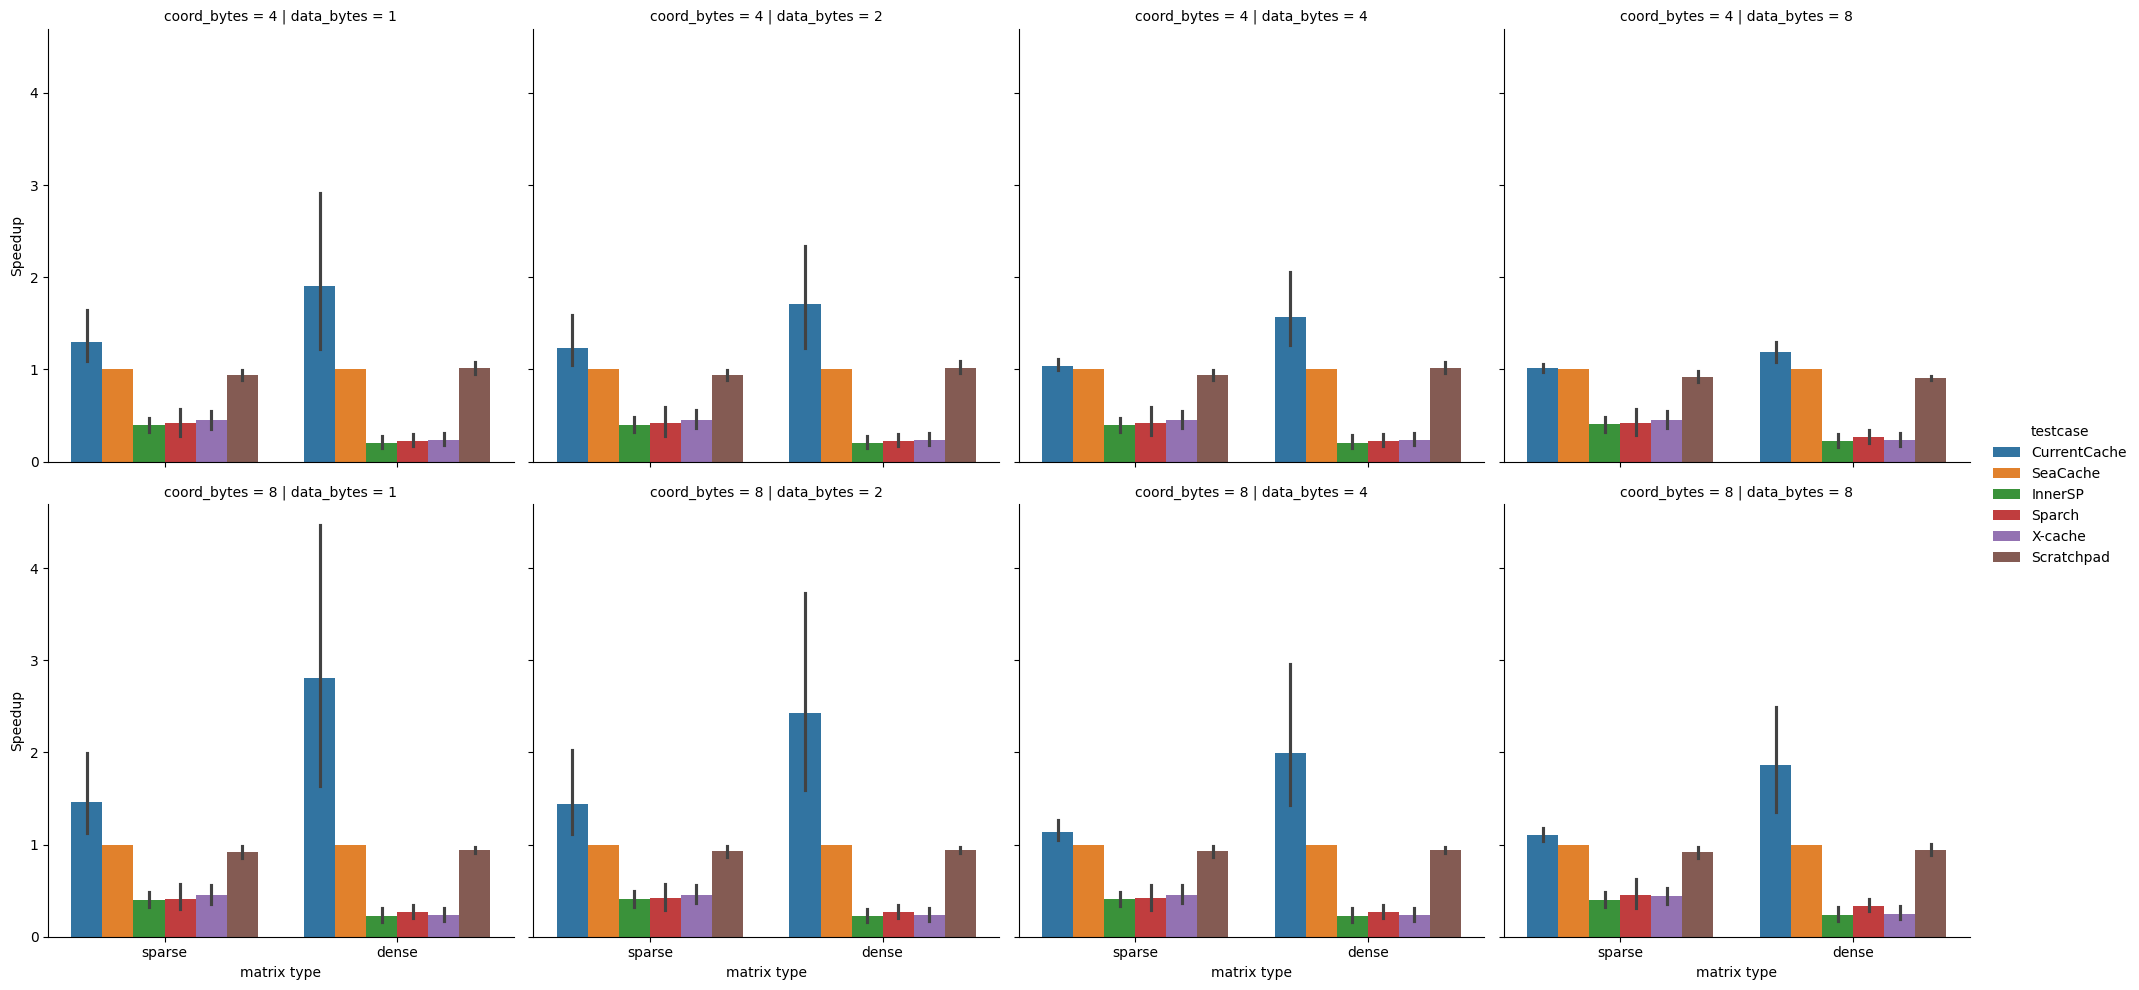

In [13]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='normalized_cyc', hue='testcase', kind='bar', x='matrix type').set_ylabels('Speedup')
plt.savefig('../renderings/relative_cycles.png')

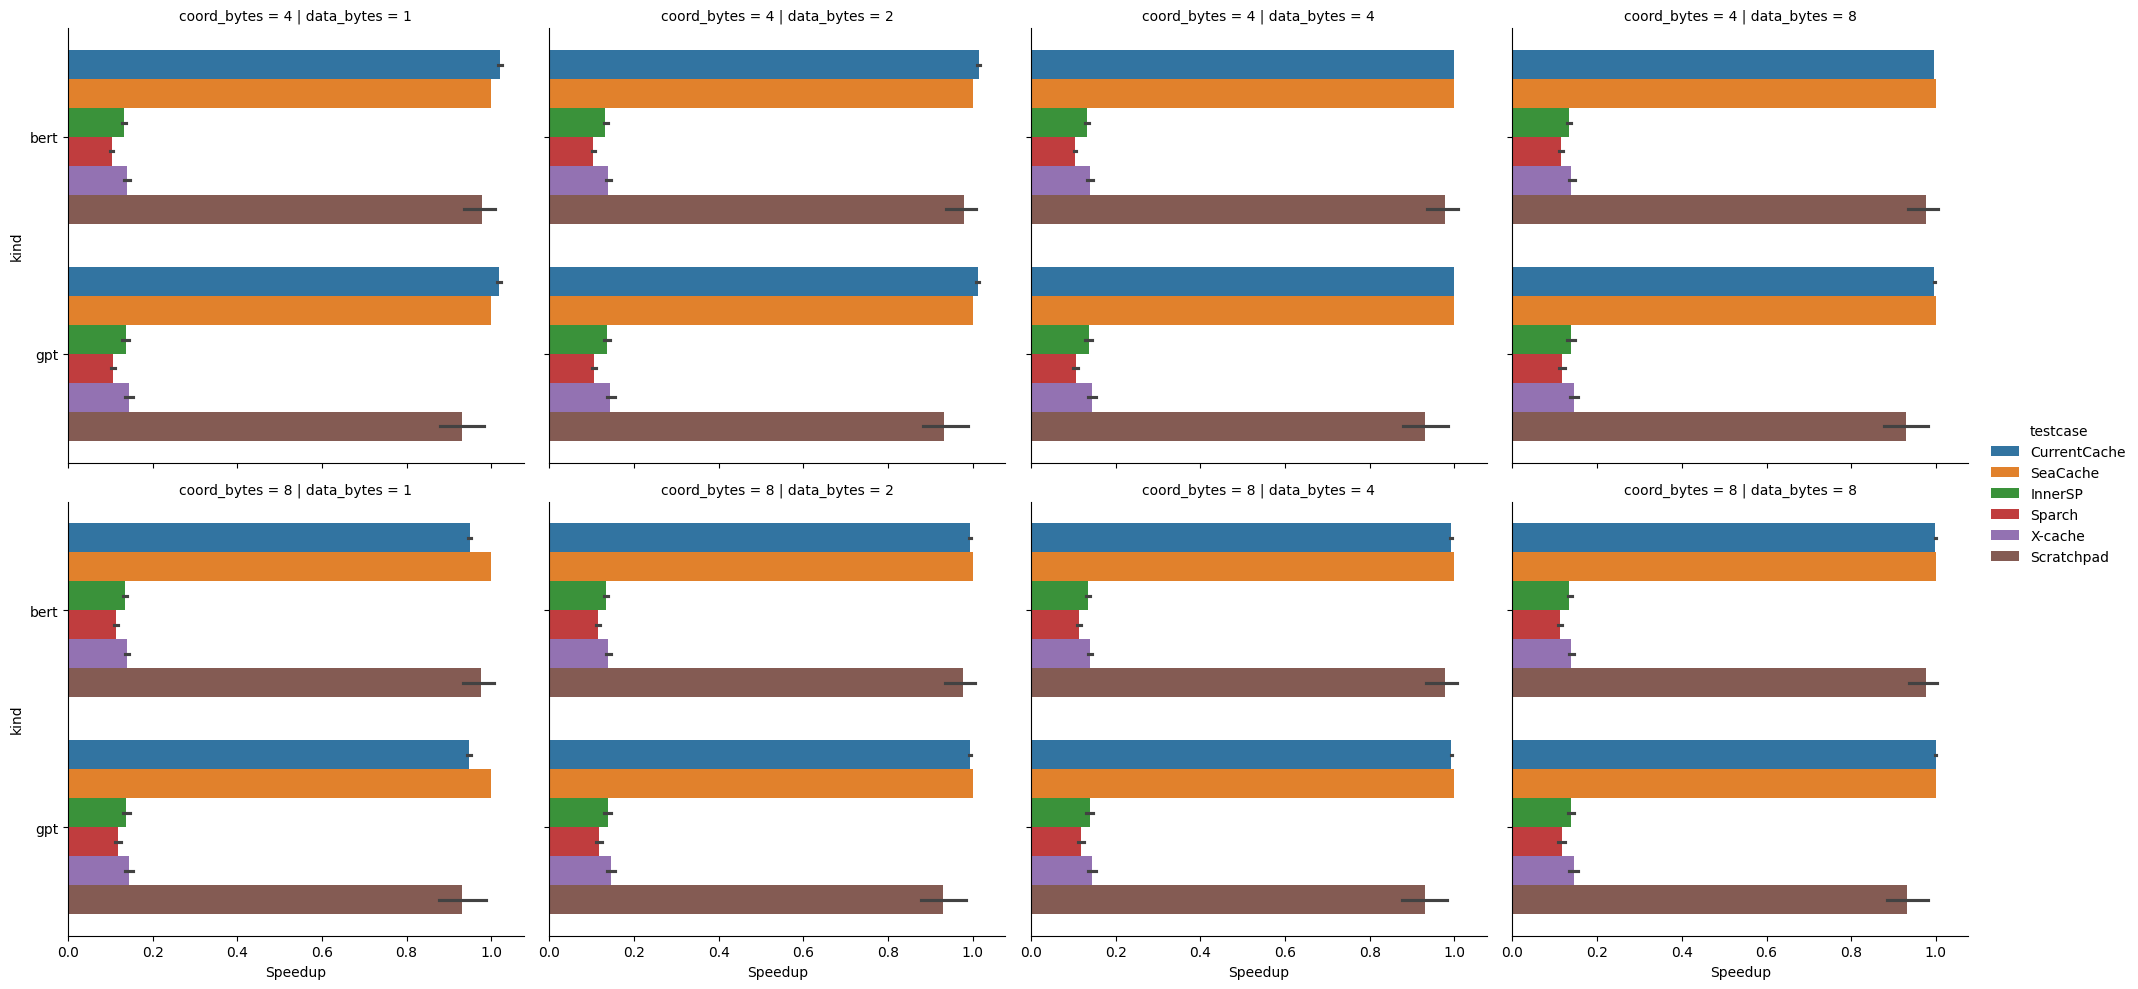

In [14]:
bert = data['matrix'].str.contains('bert')
gpt = data['matrix'].str.contains('gpt')
data['kind'] = 'general'
data.loc[bert, 'kind'] = 'bert'
data.loc[gpt, 'kind'] = 'gpt'
fig = sns.catplot(data=data.loc[bert | gpt], x='normalized_cyc', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes').set_xlabels('Speedup')
plt.savefig('../renderings/llm_sweep.png')

In [15]:
data_dir = "../output_sweep/"
sweep_files = os.listdir(data_dir)
sweep_data, _ = parse_runs(sweep_files)
sweep_data['tile'] = sweep_data.file.str.split('_').str[0].str.split('.').str[0]
sweep_data.head()

,total_cycle,load_cycle,multiply_cycle,merge_writeback_cycle,total_sram_cycle,total_dram_cycle,total_pe_cycle,total_dram_access_a,total_dram_access_b,total_dram_access_c,hitrate,file,testcase,tile
0,17636208,36720,16777216,822272,8795648,1935168,16777216,714452,435200,1644544,0.996094,256.txt,CurrentCache,256
1,63257142,36720,62398150,822272,22407851,62398150,16777216,714452,60898162,1644544,0.732779,256.txt,SeaCache,256
2,220117552,36720,219258560,822272,36721664,219258560,16777216,1392184,217080832,1644544,0.030185,256.txt,InnerSP,256
3,239371696,36720,238512704,822272,52293120,238512704,16777216,714452,237012736,1644544,0.249023,256.txt,Sparch,256
4,214505392,36720,213646400,822272,34318336,213646400,16777216,714452,212146432,1644544,0.007722,256.txt,X-cache,256


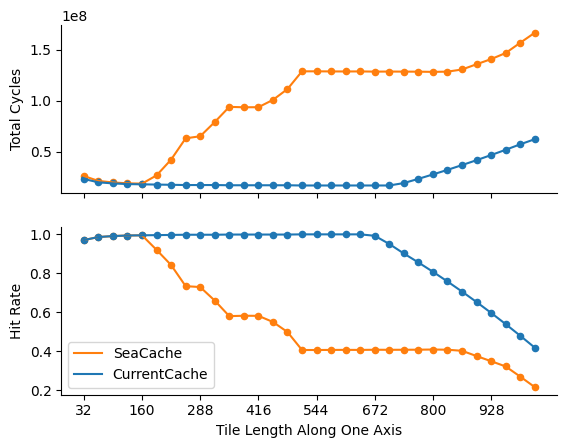

In [16]:
mask = (sweep_data.testcase == 'SeaCache') | (sweep_data.testcase == 'CurrentCache')
scache_currentcache = sweep_data.loc[mask, ['hitrate', 'total_cycle', 'testcase', 'tile']]

numeric_cols = [col for col in scache_currentcache.columns if 'file' not in col and 'testcase' not in col and 'mode' not in col and 'matrix' not in col]
for col in numeric_cols:
    scache_currentcache[col] = pd.to_numeric(scache_currentcache[col], errors='coerce')
scache_currentcache = scache_currentcache.set_index(['testcase','tile']).sort_index(level=1)

fig, (ax0, ax1) = plt.subplots(2, sharex=True)
for grp, color in zip(['SeaCache', 'CurrentCache'], ['tab:orange', 'tab:blue']):
    data = scache_currentcache.loc[(grp, slice(None)), :].reset_index(level=1, drop=False)
    data.plot(x='tile', y='hitrate', ax=ax1, label=grp, color=color)
    data.plot(x='tile', y='hitrate', ax=ax1, kind='scatter', label=None, color=color)

    data.plot(x='tile', y='total_cycle', ax=ax0, label=grp, color=color)
    data.plot(x='tile', y='total_cycle', ax=ax0, kind='scatter', label=None, color=color)


sns.despine(fig)
# sns.despine(ax=ax0, bottom=True)
ax0.set_xticks([], minor=True)
ax1.set_xticks(ticks=data.tile[::4])

ax0.set_xlabel('')
ax1.set_xlabel('Tile Length Along One Axis')

ax0.set_ylabel('Total Cycles')
ax1.set_ylabel('Hit Rate')

ax0.get_legend().remove()

# ax0.set_title('Sweep of Tile Size on Dense 1024x1024 Matrix')

plt.savefig('../renderings/dense_tile_sweep.png')